<a href="https://colab.research.google.com/github/cchan555/lis4693/blob/main/lab-7/ChanLab7April42026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 7: Sentiment Analysis
Cody Chan

## Task 1:
Use same dataset from "lab-4" and perform sentiment analysis.

In [9]:
#
# Setup for Lab 7
#

# Import Libraries
import re
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

# Load in Data
import requests
import io

url = "https://raw.githubusercontent.com/cchan555/lis4693/refs/heads/main/lab-4/sms%2Bspam%2Bcollection/SMSSpamCollection"
response = requests.get(url)
response.raise_for_status()
text = response.text

# Dataset is different from notes, need to add in tab separations
df = pd.read_csv(io.StringIO(text),
                 sep = '\t', # Tab separation
                 header = None,
                 names = ['Label', 'Message']) # Add names for each columns
print(df.head())

  Label                                            Message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [10]:
# Create new Dataframe with "id" and "text"
df_subset = df[['Label', 'Message']].copy()
df_subset = df_subset.reset_index()

# Clean text
df_subset['Message'] = df_subset['Message'].str.replace("[^a-zA-Z#]", "   ")

# Convert to Lower-case
df_subset['Message'] = df_subset['Message'].str.casefold()
print(df_subset.head(10))

  Label                                            Message
0   ham  go until jurong point, crazy.. available only ...
1   ham                      ok lar... joking wif u oni...
2  spam  free entry in 2 a wkly comp to win fa cup fina...
3   ham  u dun say so early hor... u c already then say...
4   ham  nah i don't think he goes to usf, he lives aro...
5  spam  freemsg hey there darling it's been 3 week's n...
6   ham  even my brother is not like to speak with me. ...
7   ham  as per your request 'melle melle (oru minnamin...
8  spam  winner!! as a valued network customer you have...
9  spam  had your mobile 11 months or more? u r entitle...


In [32]:
# Generate Sentiment Polarity Score
df1 = pd.DataFrame()
df1['Label'] = ['9999999999999']
df1['sentiment_type'] = 'NA99NA'
df1['sentiment_score'] = 0
print('Processing sentiment analysis...')
sid = SentimentIntensityAnalyzer()

all_scores_list = [] # Use a list to collect results

for index, row in df_subset.iterrows():
    scores = sid.polarity_scores(row['Message']) # Access by column name for clarity and robustness
    for key, value in scores.items():
        all_scores_list.append({
            'Label': row['Label'], # Access by column name
            'sentiment_type': key,
            'sentiment_score': value
        })

# Create a DataFrame from the list of dictionaries after the loop
t_df_all_types = pd.DataFrame(all_scores_list)

# Filter for compound sentiment and remove duplicates
t_df_cleaned = t_df_all_types[t_df_all_types.sentiment_type == 'compound'].drop_duplicates()

print(t_df_cleaned.head(10))

df_output = pd.merge(df, t_df_cleaned, on='Label', how='inner')
print(df_output.head(10))

Processing sentiment analysis...
   Label sentiment_type  sentiment_score
3    ham       compound           0.6249
7    ham       compound           0.4767
11  spam       compound           0.7964
15   ham       compound           0.0000
19   ham       compound          -0.1027
23  spam       compound           0.8802
27   ham       compound          -0.1331
35  spam       compound           0.9390
39  spam       compound           0.8513
43   ham       compound          -0.4257
  Label                                            Message sentiment_type  \
0   ham  Go until jurong point, crazy.. Available only ...       compound   
1   ham  Go until jurong point, crazy.. Available only ...       compound   
2   ham  Go until jurong point, crazy.. Available only ...       compound   
3   ham  Go until jurong point, crazy.. Available only ...       compound   
4   ham  Go until jurong point, crazy.. Available only ...       compound   
5   ham  Go until jurong point, crazy.. Available only

<Axes: title={'center': 'Sentiment Score'}, xlabel='Type of Message', ylabel='Mean Sentiment Score'>

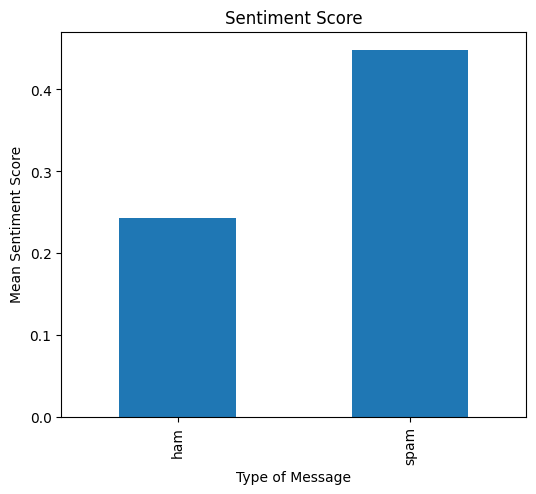

In [33]:
# Visualize Sentiment Analysis Output
df_output[["sentiment_score"]].describe()

# Generate mean of sentiment_score by Message Type
dfg = df_output.groupby(['Label'])['sentiment_score'].mean()
dfg.index = dfg.index.astype(str).str.replace(r'\.0$', '', regex=True)
# Create a bar plot
dfg.plot(kind='bar', title='Sentiment Score', ylabel='Mean Sentiment Score',
         xlabel='Type of Message', figsize=(6, 5))

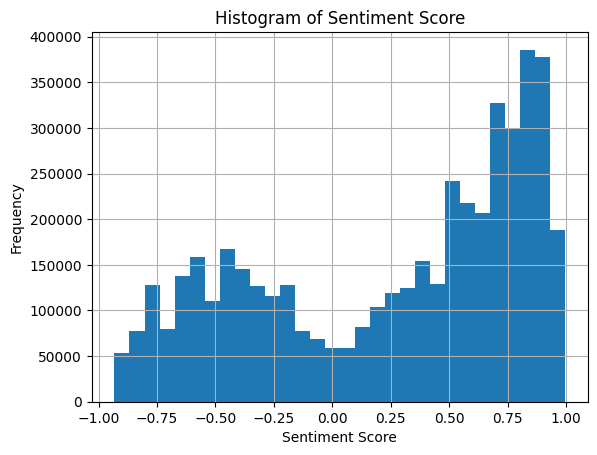

In [34]:
# Create a Histogram plot
df_output['sentiment_score'].hist(bins = 30) # Shows the distrubution
plt.title('Histogram of Sentiment Score')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency') # Amount of time it happens
plt.show()

In [37]:
# Redo graphs using Altair package
import altair as alt

# Prepare data for mean sentiment score by Message Type
dfg_type = df_output.groupby('Label')['sentiment_score'].mean().reset_index()
dfg_type['Label'] = dfg_type['Label'].astype(str).str.replace(r'\.0$', '', regex=True)

# Create the Altair bar chart for Sentiment Score by Type
chart_type = alt.Chart(dfg_type).mark_bar().encode(
    x=alt.X('Label:N', title='Type'), # Use :N for nominal (categorical) data
    y=alt.Y('sentiment_score:Q', title='Mean Sentiment Score'),
    color=alt.Color('Label:N', legend=alt.Legend(title="type")),
    tooltip=['Label', 'sentiment_score']
).properties(
    title='Mean Sentiment Score by Message Type'
).interactive()

chart_type

alt.Chart(...)

In [38]:
# Histogram with Altair
chart_hist = alt.Chart(df_output).mark_bar().encode(
    alt.X('sentiment_score:Q', bin=alt.Bin(maxbins=30), title='Sentiment Score'),
    alt.Y('count()', title='Frequency'),
    tooltip=['sentiment_score']
).properties(
    title='Histogram of Sentiment Score'
).interactive()

chart_hist

MaxRowsError: The number of rows in your dataset is greater than the maximum allowed (5000).

Try enabling the VegaFusion data transformer which raises this limit by pre-evaluating data
transformations in Python.
    >> import altair as alt
    >> alt.data_transformers.enable("vegafusion")

Or, see https://altair-viz.github.io/user_guide/large_datasets.html for additional information
on how to plot large datasets.

alt.Chart(...)

### Questions:

#### What is the 'text' field for your dataset?

#### Which common column did you choose to merge your original dataset with the sentiment scores?

#### Briefly explain your sentiment polarity results using the `describe` method.

#### Visualize and explain your sentiment result using two different visualization libaries.

## Task 2: Conclusion

### What went well? What did not go well, or what challenges did you encounter?

### In what ways could sentiment analysis be integrated into your current or future professional or research work?